# Feature Analysis by Variety Group
# 品種グループ別の特徴量分析

This notebook examines how key physical characteristics
of grapes vary across different variety groups
in the Japanese retail market.

While the previous section introduced the dataset and
overall structure, this analysis focuses on comparing
feature distributions between groups.

In this analysis, grape varieties are grouped into two categories:
Shine Muscat-type and Kyoho-type, as defined in
01_data_collection.ipynb.

This grouping enables a clearer comparison of feature patterns
across observations.

Due to the limited number of observations for each individual grape variety,
analysis at the variety level may be subject to instability
and limited reliability.

Therefore, grouping varieties into broader categories allows
for a more stable and consistent comparison of physical characteristics
across the dataset.

本Notebookでは、日本の小売市場における
ぶどうの外観特性が品種グループによって
どのように異なるかを分析します。

前節ではデータの構造や全体像を整理しましたが、
本分析ではグループ間の特徴量分布の比較に焦点を当てます。

本分析では、ぶどう品種を
シャインマスカット系と巨峰系の2つに分類しています
（詳細は 01_data_collection.ipynb を参照）。

この分類により、特徴量の分布を
より明確に比較することが可能となります。

各品種ごとのサンプル数が限られているため、
品種単位での分析には安定性や信頼性の面で制約がある可能性があります。

そのため、より広い分類単位を用いることで、
外観特性の違いを安定かつ一貫した形で比較することを目的としています。

### Feature Distribution by Variety Group/品種グループごとの特徴量分布

Boxplots are used to compare the distribution of features
across Shine Muscat-type and Kyoho-type grapes.

箱ひげ図を用いて、シャインマスカット系と巨峰系における
特徴量の分布を比較します。

In [ ]:
import pandas as pd

df = pd.read_csv("grape_data_cleaned.csv")
df.head()

,sample_id,date,grape_variety,year_introduced,database_registered,introduced_year_type,variety_generation,variety_binary,origin_prefecture,store_type,price_yen_with_tax,bunch_length_cm,bunch_width_cm,grain_diameter_mm
0,1,19/8/2025,Fujiminori,1985,1,breeding,modern,0,Yamanashi,super,1078.00,14.5,10.5,27.31
1,2,19/8/2025,Queen Seven,2015,0,breeding,new,1,Okayama,super,1078.00,15.5,12.0,20.30
2,3,19/8/2025,Delaware,1872,0,historical,old,0,Yamanashi,super,215.33,13.0,4.0,13.60
3,4,19/8/2025,Haneou,2006,1,registered,new,1,Okayama,super,3218.00,20.0,16.0,24.31
4,5,19/8/2025,Kai King,2018,1,registered,new,0,Yamanashi,super,1078.00,15.5,13.0,25.39


In [ ]:
# List of varieties classified as Shine Muscat-type (Green Group)
GREEN = "Shine Muscat-type"
PURPLE = "Kyoho-type"

green_list = [
    'Queen Seven', 'Haneou', 'Queen Rouge', 'Shine Muscat',
    'Fujinokagayaki', 'Seto Giants', 'Shigyoku', 'Shinku', 'Kaiji',
    'Queen Roug', 'Scarlet', 'Red Shine Muscat', 'Suiho',
    'Sunshine Red', 'Ving', 'Wasekaiji', 'Pizzutello Bianco',
    'Nouvelle Rose', 'Muscat Noir', 'Miwahime'
]

def grape_group(variety):
    if variety in green_list:
        return GREEN
    else:
        return PURPLE

# Apply classification
df["group"] = df["grape_variety"].apply(grape_group)

/tmp/ipykernel_18462/536172817.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_18462/536172817.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_18462/536172817.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


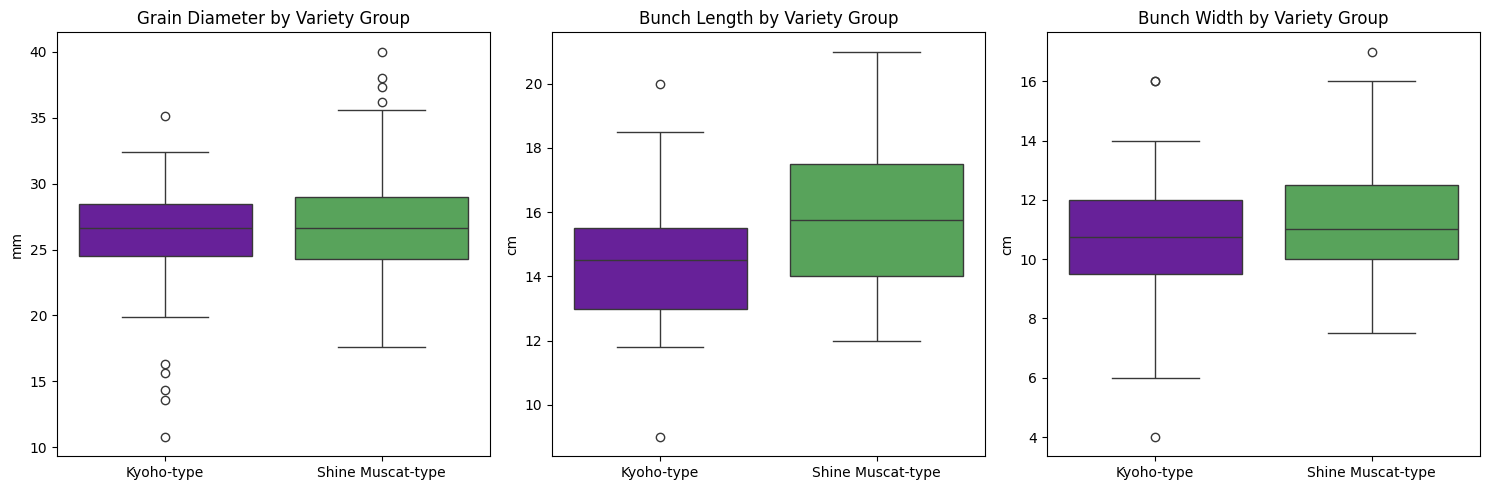

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

color_map = {
    "Shine Muscat-type": "#4CAF50",
    "Kyoho-type": "#6A0DAD"
}

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# --- 1️⃣ Grain Diameter ---
sns.boxplot(
    ax=axes[0],
    x="group",
    y="grain_diameter_mm",
    data=df,
    palette=color_map
)
axes[0].set_title("Grain Diameter by Variety Group", fontsize=12)
axes[0].set_xlabel("")
axes[0].set_ylabel("mm")

# --- 2️⃣ Bunch Length ---
sns.boxplot(
    ax=axes[1],
    x="group",
    y="bunch_length_cm",
    data=df,
    palette=color_map
)
axes[1].set_title("Bunch Length by Variety Group", fontsize=12)
axes[1].set_xlabel("")
axes[1].set_ylabel("cm")

# =--- 2️⃣ Width Length ---
sns.boxplot(
    ax=axes[2],
    x="group",
    y="bunch_width_cm",
    data=df,
    palette=color_map
)
axes[2].set_title("Bunch Width by Variety Group", fontsize=12)
axes[2].set_xlabel("")
axes[2].set_ylabel("cm")

plt.tight_layout()
plt.show()

Summary statistics such as mean and median are calculated
to quantify differences between groups.

平均値や中央値などの統計量を算出し、
グループ間の違いを定量的に把握します。

In [ ]:
features = [
    "grain_diameter_mm",
    "bunch_length_cm",
    "bunch_width_cm"
]

summary_physical = df.groupby("group")[features].agg(["mean", "median", "std"]).round(2)

summary_physical

grain_diameter_mm              bunch_length_cm               \
                               mean median   std            mean median   std   
group                                                                           
Kyoho-type                    26.32  26.64  4.05           14.67  14.50  1.82   
Shine Muscat-type             26.98  26.62  4.02           16.02  15.75  2.15   

                  bunch_width_cm               
                            mean median   std  
group                                          
Kyoho-type                 10.76  10.75  2.01  
Shine Muscat-type          11.49  11.00  1.83

###Observations: Physical Characteristics/観察結果:外観特性

The boxplots and summary statistics indicate moderate differences
between the two variety groups across physical characteristics.

For grain diameter, both groups show similar central tendencies,
with mean values of approximately 26.3 mm (Kyoho-type) and
27.0 mm (Shine Muscat-type). The distributions largely overlap,
suggesting limited separation between the groups.

In contrast, bunch length shows a clearer difference.
Shine Muscat-type grapes tend to have larger bunch sizes,
with a higher mean (16.02 cm) compared to Kyoho-type (14.67 cm),
as also reflected in the upward shift of the distribution.

Bunch width exhibits a similar but more moderate pattern,
with Shine Muscat-type showing slightly higher average values
(11.49 cm vs 10.76 cm), although the distributions still overlap.

Overall, while differences in physical characteristics exist,
particularly in bunch size, variability within each group remains substantial.

These differences may contribute to price variation,
which will be examined in the following sections.

箱ひげ図および統計量から、外観特性において
2つの品種グループ間に一定の違いが見られます。

粒径については、両グループの中心傾向は類似しており、
平均値は巨峰系が約26.3 mm、シャインマスカット系が約27.0 mmとなっています。
分布も大きく重なっており、明確な差は限定的です。

一方、房の長さではより明確な違いが見られ、
シャインマスカット系の方が平均値（16.02 cm）が高く、
巨峰系（14.67 cm）よりも大きい傾向が確認されます。
箱ひげ図でも分布が全体的に上方に位置しています。

房の幅についても同様の傾向が見られ、
シャインマスカット系はやや高い平均値（11.49 cm）を示していますが、
分布の重なりは依然として存在します。

全体として、外観特性には一定のグループ差が見られるものの、
各グループ内のばらつきも大きいことが確認されます。

これらの違いが価格差にどのように関与するかについては、
後続の分析で検討します

### Year Introduced by Variety Group/品種導入年の比較

A horizontal boxplot is used to examine differences
in the distribution of introduction years across groups.

Median values are used as the primary reference,
while mean and mode provide additional context.

This approach allows for a more comprehensive understanding
of how variety age differs between groups.

横向きの箱ひげ図を用いて、
品種グループごとの導入年の分布を確認します。

代表値として中央値を主に参照し、
平均値や最頻値も補助的に用います。

これにより、品種の新しさの違いを
より包括的に把握することができます

/tmp/ipykernel_18462/932180684.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


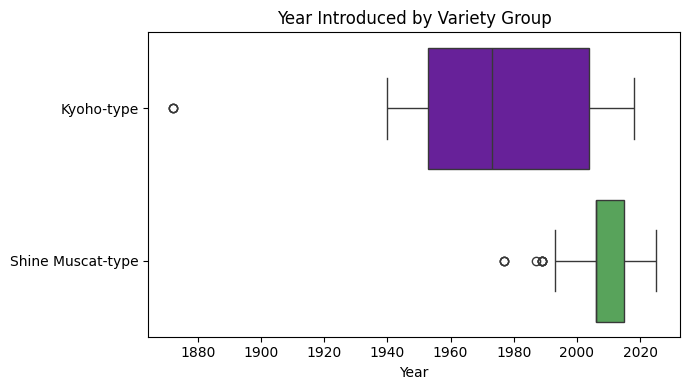

In [ ]:
plt.figure(figsize=(7,4))

sns.boxplot(
    x="year_introduced",
    y="group",
    data=df,
    palette=color_map
)

plt.title("Year Introduced by Variety Group")
plt.xlabel("Year")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [ ]:
summary_year = df.groupby("group")["year_introduced"].agg([
    "mean",
    "median",
    lambda x: x.mode().iloc[0] if not x.mode().empty else None
])

summary_year.columns = ["mean", "median", "mode"]
summary_year.round(1)

,mean,median,mode
group,,,
Kyoho-type,1977.8,1973.0,1973
Shine Muscat-type,2007.1,2006.0,2006


###Observations: Year Introduced/観察結果：品種導入年

The summary statistics indicate a clear difference in the introduction period between the two variety groups.

Kyoho-type grapes have a median introduction year of 1973, while Shine Muscat-type grapes are centered around 2006.

This suggests that Shine Muscat-type varieties are generally more recently developed compared to Kyoho-type varieties.

However, variation within each group is still present, indicating that both older and newer varieties exist within each category.

The summary statistics indicate a clear difference in the introduction period between the two variety groups.

統計量から、2つの品種グループの導入時期には 明確な違いが見られます。

巨峰系の中央値は1973年であるのに対し、 シャインマスカット系は2006年付近に集中しています。

このことから、シャインマスカット系は 比較的新しい品種が多い傾向にあると考えられます。

一方で、各グループ内にはばらつきも存在しており、 それぞれのグループにおいて新旧の品種が混在していることも確認されます。

## Summary of Feature Analysis/特徴量分析のまとめ

The analysis of physical characteristics and introduction year
reveals structural differences between the two variety groups.

In terms of physical features, grain diameter shows only minor
differences between groups, with substantial overlap in distributions.
In contrast, bunch size—particularly bunch length—tends to be larger
for Shine Muscat-type grapes, indicating a clearer distinction
in appearance-related characteristics.

For year introduced, a clear separation is observed.
Kyoho-type varieties are centered around earlier periods
(median: 1973), while Shine Muscat-type varieties are more recent
(median: 2006), suggesting differences in development timelines.

However, variability within each group remains notable across
all features, indicating that these differences are not uniform
and should be interpreted as general tendencies rather than
definitive distinctions.

Overall, the results suggest that while variety groups exhibit
certain structural differences in both physical characteristics
and variety age, these factors alone do not fully separate the groups.

外観特性および導入年の分析から、
2つの品種グループ間に一定の構造的な違いが確認されました。

外観特性に関しては、粒径は両グループで大きな差は見られず、
分布の重なりも大きいことが分かります。
一方で、房サイズ、特に房の長さについては、
シャインマスカット系の方が大きい傾向が見られ、
外観上の違いが比較的明確に現れています。

導入年についてはより明確な差が確認され、
巨峰系は1973年付近を中心とする一方で、
シャインマスカット系は2006年付近に集中しており、
品種開発の時期に違いがあることが示唆されます。

ただし、いずれの特徴量においてもグループ内のばらつきは大きく、
これらの違いはあくまで傾向として捉える必要があります。

総合的に見ると、品種グループ間には
外観特性および品種の新しさにおいて一定の違いが存在するものの、
それらだけで完全に区別できるわけではないことが示されています。